# Catalog Cell Coverage: Disc Query vs Vertex-to-Morton vs Buffer

The granule catalog maps parent morton cells to ICESat-2 ATL06 granule S3 URLs.
Several approaches exist for determining which cells to include:

1. **Disc query**: Per-basin centroid + max radius → `healpy.query_disc` → merge unique cells.
2. **Vertex-to-morton (raw)**: CMR polygon vertices → `geo2mort` → `clip2order` (~1,742 cells).
3. **Vertex-to-morton (densified)**: Same with 5km interpolation along polygon edges (~2,395 cells).
4. **Vertex + buffer**: Expand a vertex set by one cell via `morton_buffer(cells, k=1)`.

**Ground truth**: The production Lambda run (`production_results_20260218_155320.json`,
cycle 22) processed all 2,395 densified-catalog cells. Each cell's Lambda response
includes a `body.total_obs` count. Cells with `total_obs > 0` are the ground truth —
**1,739 cells** that actually contain ATL06 observations. This is bounded by what the
densified catalog covers; cells outside that catalog were never queried.

In [ ]:
import numpy as np
import pandas as pd
import healpy as hp
from mortie import geo2mort, clip2order, mort2geo, morton_buffer
from magg.catalog import query_cmr_antarctica, build_morton_catalog, build_morton_catalog_polygon
import json
import time
import logging

logging.basicConfig(level=logging.INFO)

In [2]:
# Load drainage basin polygons
basin_file = "Ant_Grounded_DrainageSystem_Polygons.txt"
df = pd.read_csv(basin_file, names=["Lat", "Lon", "basin"], sep=r"\s+")

n_basins = df["basin"].nunique()
print(f"Basins: {n_basins}")
print(f"Total vertices: {len(df):,}")
print(f"Lat range: [{df['Lat'].min():.2f}, {df['Lat'].max():.2f}]")
print(f"Lon range: [{df['Lon'].min():.2f}, {df['Lon'].max():.2f}]")

Basins: 27
Total vertices: 1,239,001
Lat range: [-88.45, -63.21]
Lon range: [-179.99, 180.00]


In [3]:
# --- Approach 1: Disc Query ---
# Reuse logic from lambda/test_antarctic_cells.py

def latlon_to_xyz(lats, lons):
    """Convert lat/lon arrays to 3D unit vectors."""
    lat_rad = np.radians(lats)
    lon_rad = np.radians(lons)
    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)
    return np.column_stack([x, y, z])


def compute_bounding_disc(lats, lons):
    """Compute bounding disc (centroid_vec, radius_radians) for lat/lon points."""
    xyz = latlon_to_xyz(lats, lons)
    centroid = xyz.mean(axis=0)
    centroid = centroid / np.linalg.norm(centroid)
    dots = np.clip(xyz @ centroid, -1.0, 1.0)
    radius = np.arccos(dots.min())
    return centroid, radius


def healpix_to_morton(pixels, nside, order):
    """Convert HEALPix NEST pixels to morton indices at given order."""
    theta, phi = hp.pix2ang(nside, pixels, nest=True)
    lats = 90 - np.degrees(theta)
    lons = np.degrees(phi)
    lons[lons > 180] -= 360
    m18 = geo2mort(lats, lons, order=18)
    return set(int(x) for x in clip2order(order, m18))


order = 6
nside = 2 ** order

t0 = time.time()
all_healpix = []
basin_stats = []

for basin_id in sorted(df["basin"].unique()):
    bdf = df[df["basin"] == basin_id]
    lats, lons = bdf["Lat"].values, bdf["Lon"].values
    centroid, radius = compute_bounding_disc(lats, lons)
    pixels = hp.query_disc(nside, centroid, radius, inclusive=True, nest=True)
    all_healpix.append(pixels)
    basin_stats.append({
        "basin": basin_id,
        "vertices": len(lats),
        "healpix": len(pixels),
        "radius_deg": np.degrees(radius),
    })

all_hp = np.unique(np.concatenate(all_healpix))
disc_cells = healpix_to_morton(all_hp, nside, order)
disc_time = time.time() - t0

stats_df = pd.DataFrame(basin_stats)
print(f"Disc query: {len(disc_cells)} cells in {disc_time:.2f}s")
print(f"\nPer-basin stats:")
display(stats_df)

Disc query: 2079 cells in 0.11s

Per-basin stats:


,basin,vertices,healpix,radius_deg
0,1,81595,223,7.056491
1,2,43096,505,10.868841
2,3,72275,500,10.817811
3,4,42405,126,5.145137
4,5,26716,103,4.529813
5,6,57276,191,6.502413
6,7,66599,262,7.626811
7,8,36631,86,4.100181
8,9,23734,75,3.751962
9,10,42782,191,6.429788


In [4]:
# --- Ground Truth: Production Lambda Results ---
# Source: production_results_20260218_155320.json (cycle 22, full run)
# This ran ALL 2,395 cells from the densified catalog.
# Each result body includes total_obs — cells with total_obs > 0 have data.
# Note: ground truth is bounded by the densified catalog; cells outside it
# were never queried, so we can't know if they have data.

with open("production_results_20260218_155320.json") as f:
    prod = json.load(f)

ground_truth = set()
cell_obs = {}
for r in prod["results"]:
    body = r.get("body", {})
    obs = body.get("total_obs", 0) if isinstance(body, dict) else 0
    if obs > 0:
        ground_truth.add(r["morton"])
        cell_obs[r["morton"]] = obs

print(f"Ground truth: {len(ground_truth)} cells with total_obs > 0")
print(f"  Total observations: {sum(cell_obs.values()):,}")
print(f"  Source: densified catalog ({prod['summary']['total_cells']} cells queried, "
      f"{prod['summary']['cells_no_data']} returned no data)")

Ground truth: 1739 cells with total_obs > 0
  Total observations: 1,370,185,727
  Source: densified catalog (2395 cells queried, 656 returned no data)


/tmp/ipykernel_1669765/1800149964.py:48: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  la = float(mort2geo(m)[0])
/tmp/ipykernel_1669765/1800149964.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lo = float(mort2geo(m)[1])


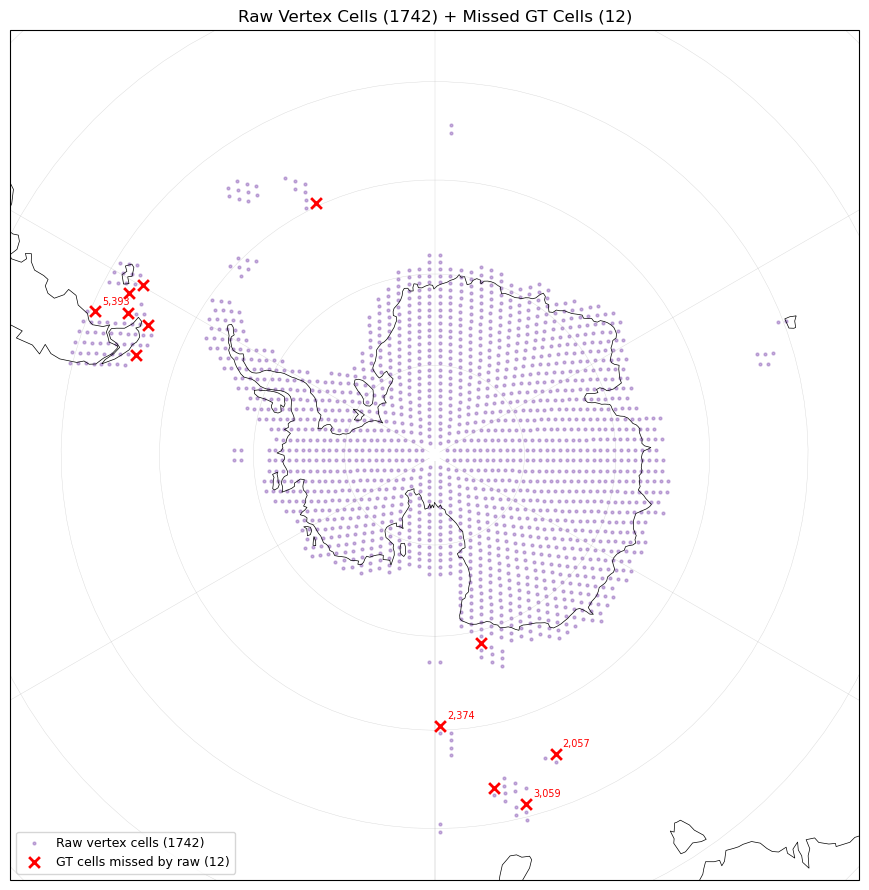


    morton      lat       lon        obs  location
------------------------------------------------------------
  -6321111   -53.57    -59.69        112
  -6312434   -50.48    -67.08      5,393
  -6312312   -55.87    -71.41        121
  -6312242   -52.80    -62.10        167
  -6312234   -53.57    -65.20        150
  -6312213   -55.87    -65.54        277
  -6124234   -59.68    -25.24         12
  -4214122   -51.26    165.29      3,059
  -4213144   -55.11    157.98      2,057
  -4212324   -53.57    169.90         41
  -4211222   -60.43    178.88      2,374
  -4122311   -68.68    166.03          8

Total missed obs: 13,771 / 1,370,185,727 (0.0010%)


/tmp/ipykernel_1669765/1800149964.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  la = float(mort2geo(m)[0])
/tmp/ipykernel_1669765/1800149964.py:68: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lo_raw = float(mort2geo(m)[1])


In [5]:
# --- Upfront Plot: Raw Vertex Coverage + Missing Cells ---
# Show all raw vertex morton cells and overlay the ground-truth cells
# that raw vertices miss.

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def cells_to_latlon(cells):
    """Convert morton cell set to lat/lon arrays via mort2geo."""
    arr = np.array(sorted(cells))
    lats, lons = mort2geo(arr)
    return np.asarray(lats), np.asarray(lons)

proj = ccrs.SouthPolarStereo()
geo = ccrs.PlateCarree()

# Load raw cells early (before the vertex-nodensify cell runs the full setup)
try:
    with open("granule_catalog_cycle22_order6_nodensify.json") as f:
        _raw = json.load(f)
    raw_cells_preview = set(int(k) for k in _raw["catalog"].keys())
except FileNotFoundError:
    raw_cells_preview = set()
    print("Non-densified catalog not yet built — run cell below first")

if raw_cells_preview:
    missed_preview = ground_truth - raw_cells_preview
    r_la, r_lo = cells_to_latlon(raw_cells_preview)

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": proj})
    ax.set_extent([-180, 180, -90, -45], crs=geo)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)

    ax.scatter(r_lo, r_la, s=4, c="tab:purple", transform=geo, alpha=0.5,
               label=f"Raw vertex cells ({len(raw_cells_preview)})")

    if missed_preview:
        m_la, m_lo = cells_to_latlon(missed_preview)
        ax.scatter(m_lo, m_la, s=60, c="red", marker="x", transform=geo,
                   zorder=5, linewidths=2,
                   label=f"GT cells missed by raw ({len(missed_preview)})")

        # Annotate observation counts
        missed_sorted = sorted(missed_preview)
        for m in missed_sorted:
            la = float(mort2geo(m)[0])
            lo = float(mort2geo(m)[1])
            obs = cell_obs.get(m, 0)
            if obs > 1000:
                ax.annotate(f"{obs:,}", xy=(lo, la), xytext=(5, 5),
                            textcoords="offset points", fontsize=7,
                            color="red", transform=geo)

    ax.set_title(f"Raw Vertex Cells ({len(raw_cells_preview)}) + "
                 f"Missed GT Cells ({len(missed_preview)})", fontsize=12)
    ax.legend(loc="lower left", fontsize=9)
    plt.tight_layout()
    plt.show()

    # Print missed cell details with observation counts
    print(f"\n{'morton':>10} {'lat':>8} {'lon':>9} {'obs':>10}  location")
    print("-" * 60)
    total_missed_obs = 0
    for m in sorted(missed_preview):
        la = float(mort2geo(m)[0])
        lo_raw = float(mort2geo(m)[1])
        lo = lo_raw - 360 if lo_raw > 180 else lo_raw
        obs = cell_obs.get(m, 0)
        total_missed_obs += obs
        print(f"{m:>10} {la:>8.2f} {lo:>9.2f} {obs:>10,}")
    print(f"\nTotal missed obs: {total_missed_obs:,} / {sum(cell_obs.values()):,} "
          f"({100*total_missed_obs/sum(cell_obs.values()):.4f}%)")

In [6]:
# --- Approach 2a: Vertex-to-Morton (NO densification) ---
# Query CMR for cycle 22 granules, build catalog without densification.
# Cache result to avoid re-querying on subsequent runs.

cache_file = "granule_catalog_cycle22_order6_nodensify.json"

try:
    with open(cache_file) as f:
        raw_catalog_data = json.load(f)
    print(f"Loaded cached non-densified catalog from {cache_file}")
except FileNotFoundError:
    print("Querying CMR for cycle 22 granules...")
    granules = query_cmr_antarctica(cycle=22, version="007")
    print(f"Got {len(granules)} granules, building non-densified catalog...")
    raw_catalog = build_morton_catalog(granules, parent_order=6, densify=False)

    raw_catalog_data = {
        "metadata": {
            "cycle": 22, "parent_order": 6, "version": "007",
            "densify": False, "total_granules": len(granules),
            "total_cells": len(raw_catalog),
        },
        "catalog": {str(k): v for k, v in raw_catalog.items()},
    }
    with open(cache_file, "w") as f:
        json.dump(raw_catalog_data, f, indent=2)
    print(f"Saved to {cache_file}")

raw_cells = set(int(k) for k in raw_catalog_data["catalog"].keys())
print(f"\nVertex-to-morton (raw, no densify): {len(raw_cells)} cells")
for k, v in raw_catalog_data["metadata"].items():
    print(f"  {k}: {v}")

Loaded cached non-densified catalog from granule_catalog_cycle22_order6_nodensify.json

Vertex-to-morton (raw, no densify): 1742 cells
  cycle: 22
  parent_order: 6
  version: 007
  densify: False
  total_granules: 4153
  total_cells: 1742


In [7]:
# --- Approach 2b: Vertex-to-Morton (densified, 5km spacing) ---
# Load pre-built catalog.

with open("granule_catalog_cycle22_order6.json") as f:
    catalog_data = json.load(f)

dense_cells = set(int(k) for k in catalog_data["catalog"].keys())
print(f"Vertex-to-morton (densified): {len(dense_cells)} cells")
for k, v in catalog_data["metadata"].items():
    print(f"  {k}: {v}")

# Granule density stats
counts = np.array([len(v) for v in catalog_data["catalog"].values()])
print(f"\nGranules per cell: min={counts.min()}, median={int(np.median(counts))}, "
      f"mean={counts.mean():.1f}, max={counts.max()}")

Vertex-to-morton (densified): 2395 cells
  cycle: 22
  parent_order: 6
  version: 007
  south_of: -60.0
  densify: True
  densify_spacing_km: 5.0
  total_granules: 4153
  total_cells: 2395
  created: 2026-02-18T15:42:37.932543

Granules per cell: min=1, median=28, mean=38.2, max=395


In [ ]:
# --- Approach 4: Polygon Intersection (exact, no densification) ---
# Uses shapely STRtree to test which granule polygons intersect each cell.
# All geometry in EPSG:3031 to avoid antimeridian/pole issues.

poly_cache = "granule_catalog_cycle22_order6_polygon.json"

try:
    with open(poly_cache) as f:
        poly_catalog_data = json.load(f)
    poly_cat = poly_catalog_data["catalog"]
    poly_timings = poly_catalog_data.get("timings", {})
    print(f"Loaded cached polygon intersection catalog from {poly_cache}")
except FileNotFoundError:
    print("Querying CMR for cycle 22 granules...")
    granules = query_cmr_antarctica(cycle=22, version="007")
    print(f"Got {len(granules)} granules, building polygon intersection catalog...")
    poly_cat_raw, poly_timings = build_morton_catalog_polygon(granules, parent_order=6)

    poly_catalog_data = {
        "metadata": {
            "cycle": 22, "parent_order": 6, "version": "007",
            "method": "polygon_intersection",
            "total_granules": len(granules),
            "total_cells": len(poly_cat_raw),
        },
        "timings": poly_timings,
        "catalog": {str(k): v for k, v in poly_cat_raw.items()},
    }
    with open(poly_cache, "w") as f:
        json.dump(poly_catalog_data, f, indent=2)
    print(f"Saved to {poly_cache}")
    poly_cat = poly_catalog_data["catalog"]

poly_cells = set(int(k) for k in poly_cat.keys())
print(f"\nPolygon intersection: {len(poly_cells)} cells")

# Granule density stats
poly_counts = np.array([len(v) for v in poly_cat.values()])
print(f"Granules per cell: min={poly_counts.min()}, median={int(np.median(poly_counts))}, "
      f"mean={poly_counts.mean():.1f}, max={poly_counts.max()}")

# Timing breakdown
if poly_timings:
    print(f"\nPipeline timing breakdown:")
    for step, sec in poly_timings.items():
        print(f"  {step:<25s} {sec:.3f}s")

# Compare per-cell granule counts: polygon vs raw vs densified
raw_cat_ref = raw_catalog_data["catalog"]
dense_cat_ref = catalog_data["catalog"]

shared_poly_raw = poly_cells & raw_cells
poly_has_more = sum(
    1 for c in shared_poly_raw
    if len(poly_cat[str(c)]) > len(raw_cat_ref.get(str(c), []))
)
print(f"\nPer-cell comparison (polygon vs raw, {len(shared_poly_raw)} shared cells):")
print(f"  Cells where polygon finds more granules: {poly_has_more}")

shared_poly_dense = poly_cells & dense_cells
poly_vs_dense_diff = []
for c in shared_poly_dense:
    pg = len(poly_cat[str(c)])
    dg = len(dense_cat_ref[str(c)])
    poly_vs_dense_diff.append(pg - dg)
diffs = np.array(poly_vs_dense_diff)
print(f"Per-cell comparison (polygon vs densified, {len(shared_poly_dense)} shared cells):")
print(f"  Polygon has more: {np.sum(diffs > 0)}, equal: {np.sum(diffs == 0)}, "
      f"fewer: {np.sum(diffs < 0)}")
print(f"  Mean difference: {diffs.mean():.2f}, max: {diffs.max()}, min: {diffs.min()}")

In [8]:
# --- Approach 3a: Raw Vertex + Buffer (THE KEY TEST) ---
# Buffer the non-densified vertex set. This is the candidate "best of both
# worlds" approach: tight vertex coverage + 1-cell expansion to catch
# pole-hole edge cells without densification overhead.

raw_arr = np.array(sorted(raw_cells))

t0 = time.time()
raw_border = morton_buffer(raw_arr, k=1)
raw_buffered_cells = set(np.union1d(raw_arr, raw_border).astype(int))
raw_buf_time = time.time() - t0

print(f"Raw vertex cells:        {len(raw_cells)}")
print(f"Border ring (new cells): {len(raw_border)}")
print(f"Raw + buffer total:      {len(raw_buffered_cells)}")
print(f"Buffer expansion:        +{len(raw_buffered_cells) - len(raw_cells)} cells "
      f"({100*(len(raw_buffered_cells)/len(raw_cells) - 1):.1f}%)")
print(f"Time: {raw_buf_time:.3f}s")

Raw vertex cells:        1742
Border ring (new cells): 504
Raw + buffer total:      2246
Buffer expansion:        +504 cells (28.9%)
Time: 0.003s


In [9]:
# --- Approach 3b: Densified Vertex + Buffer (for comparison) ---

dense_arr = np.array(sorted(dense_cells))

t0 = time.time()
dense_border = morton_buffer(dense_arr, k=1)
dense_buffered_cells = set(np.union1d(dense_arr, dense_border).astype(int))
dense_buf_time = time.time() - t0

print(f"Dense vertex cells:      {len(dense_cells)}")
print(f"Border ring (new cells): {len(dense_border)}")
print(f"Dense + buffer total:    {len(dense_buffered_cells)}")
print(f"Buffer expansion:        +{len(dense_buffered_cells) - len(dense_cells)} cells "
      f"({100*(len(dense_buffered_cells)/len(dense_cells) - 1):.1f}%)")
print(f"Time: {dense_buf_time:.3f}s")

Dense vertex cells:      2395
Border ring (new cells): 529
Dense + buffer total:    2924
Buffer expansion:        +529 cells (22.1%)
Time: 0.004s


In [10]:
# --- Approach 3c: Selective Buffer (south of cutoff only) ---
# Hypothesis: the 12 missed cells are near the pole hole, so we can
# buffer only the southernmost cells to minimize false positives.
# Test with -80° cutoff, then sweep to find what's actually needed.

raw_lats = np.asarray(mort2geo(raw_arr)[0])

# Selective buffer at -80°S
cutoff = -80.0
south_mask = raw_lats <= cutoff
south_cells = raw_arr[south_mask]
south_border = morton_buffer(south_cells, k=1)
selective_buffered = raw_cells | set(int(x) for x in south_border)

sel_hits = len(selective_buffered & ground_truth)
sel_missed = len(ground_truth - selective_buffered)
print(f"Selective buffer (south of {cutoff}°):")
print(f"  Southern cells buffered: {len(south_cells)}/{len(raw_cells)}")
print(f"  New cells added:         {len(selective_buffered) - len(raw_cells)}")
print(f"  Total:                   {len(selective_buffered)}")
print(f"  Missed GT cells:         {sel_missed}")
print()

# Where are the 12 missed cells actually?
missed_12 = ground_truth - raw_cells
m_arr = np.array(sorted(missed_12))
m_la, m_lo = mort2geo(m_arr)
print("The 12 missed ground-truth cells are NOT near the pole:")
for i in range(len(m_arr)):
    print(f"  morton={m_arr[i]:>10}  lat={m_la[i]:>7.2f}  lon={m_lo[i]:>8.2f}")

# Sweep cutoffs to find what's needed
print(f"\nCutoff sweep:")
print(f"{'Cutoff':>8} {'Buffered':>9} {'Added':>6} {'Total':>6} {'Missed':>7} {'FP':>5}")
for c in [-50, -55, -60, -65, -70, -75, -80]:
    mask = raw_lats <= c
    sc = raw_arr[mask]
    bdr = morton_buffer(sc, k=1)
    sel = raw_cells | set(int(x) for x in bdr)
    m = len(ground_truth - sel)
    fp = len(sel - ground_truth)
    print(f"{c:>8} {len(sc):>9} {len(sel)-len(raw_cells):>6} {len(sel):>6} {m:>7} {fp:>5}")

print("\nConclusion: missed cells are at -50° to -69° (sparse polygon edges,")
print("not pole hole). Selective buffer at -80° adds only 4 cells and")
print("captures none of the 12. Full buffer is needed for 100% recall.")

Selective buffer (south of -80.0°):
  Southern cells buffered: 360/1742
  New cells added:         4
  Total:                   1746
  Missed GT cells:         12

The 12 missed ground-truth cells are NOT near the pole:
  morton=  -6321111  lat= -53.57  lon=  300.31
  morton=  -6312434  lat= -50.48  lon=  292.92
  morton=  -6312312  lat= -55.87  lon=  288.59
  morton=  -6312242  lat= -52.80  lon=  297.90
  morton=  -6312234  lat= -53.57  lon=  294.80
  morton=  -6312213  lat= -55.87  lon=  294.46
  morton=  -6124234  lat= -59.68  lon=  334.76
  morton=  -4214122  lat= -51.26  lon=  165.29
  morton=  -4213144  lat= -55.11  lon=  157.98
  morton=  -4212324  lat= -53.57  lon=  169.90
  morton=  -4211222  lat= -60.43  lon=  178.88
  morton=  -4122311  lat= -68.68  lon=  166.03

Cutoff sweep:
  Cutoff  Buffered  Added  Total  Missed    FP
     -50      1733    487   2229       0   490
     -55      1665    386   2128       5   394
     -60      1634    305   2047      11   319
     -65     

In [ ]:
# --- Set Comparison vs Ground Truth ---
# Ground truth = 1,739 cells that actually returned data in production.

approaches = {
    "Disc query":            disc_cells,
    "Vertex (raw)":          raw_cells,
    "Vertex (densified)":    dense_cells,
    "Polygon intersection":  poly_cells,
    "Raw + buffer(k=1)":     raw_buffered_cells,
    "Raw + sel.buf(-80)":    selective_buffered,
    "Dense + buffer(k=1)":   dense_buffered_cells,
}

def jaccard(a, b):
    return len(a & b) / len(a | b) if (a | b) else 1.0

print(f"Ground truth: {len(ground_truth)} cells with data\n")
print(f"{'Approach':<22} {'Cells':>6} {'Hits':>6} {'Missed':>7} {'Empty':>6} {'Hit%':>6}  {'Jaccard':>7}")
print("-" * 72)

for name, cells in approaches.items():
    hits   = len(cells & ground_truth)       # true positives
    missed = len(ground_truth - cells)       # false negatives
    empty  = len(cells - ground_truth)       # false positives
    hit_pct = 100 * hits / len(cells)
    j = jaccard(cells, ground_truth)
    print(f"{name:<22} {len(cells):>6} {hits:>6} {missed:>7} {empty:>6} {hit_pct:>5.1f}%  {j:>7.4f}")

In [ ]:
# --- Visualization: Polar Stereographic Coverage Maps ---
# (cells_to_latlon, proj, geo defined in upfront plot cell above)

fig, axes = plt.subplots(2, 4, figsize=(22, 11),
                         subplot_kw={"projection": proj})

panels = [
    (axes[0, 0], disc_cells,          "Disc Query",             "tab:red"),
    (axes[0, 1], raw_cells,           "Vertex (raw)",           "tab:purple"),
    (axes[0, 2], dense_cells,         "Vertex (densified)",     "tab:blue"),
    (axes[0, 3], poly_cells,          "Polygon Intersection",   "tab:olive"),
    (axes[1, 0], ground_truth,        "Ground Truth",           "black"),
    (axes[1, 1], raw_buffered_cells,  "Raw + Buffer(k=1)",      "tab:orange"),
    (axes[1, 2], selective_buffered,  "Raw + Sel.Buf(-80)",     "tab:cyan"),
    (axes[1, 3], dense_buffered_cells,"Dense + Buffer(k=1)",    "tab:green"),
]

for ax, cells, title, color in panels:
    ax.set_extent([-180, 180, -90, -60], crs=geo)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)
    lats, lons = cells_to_latlon(cells)
    ax.scatter(lons, lats, s=4, c=color, transform=geo, alpha=0.6)
    ax.set_title(f"{title} ({len(cells)} cells)", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# --- Cost / Coverage Table vs Ground Truth ---
cost_per_cell = 0.00124  # ~$0.00124 per Lambda invocation (128MB, ~1s avg)

def make_row(name, cells):
    hits   = len(cells & ground_truth)
    missed = len(ground_truth - cells)
    empty  = len(cells - ground_truth)
    return {
        "Approach": name,
        "Total cells": len(cells),
        "True positives": hits,
        "False negatives": missed,
        "False positives": empty,
        "Recall": f"{100*hits/len(ground_truth):.1f}%",
        "Precision": f"{100*hits/len(cells):.1f}%",
        "Est. cost": f"${len(cells)*cost_per_cell:.2f}",
    }

rows = [make_row(name, cells) for name, cells in approaches.items()]

print(f"Ground truth: {len(ground_truth)} cells with data\n")
display(pd.DataFrame(rows).set_index("Approach"))

Disc query             misses 140 ground-truth cells (lat range [-68.7, -49.7], 0 near pole)
Vertex (raw)           misses  12 ground-truth cells (lat range [-68.7, -50.5], 0 near pole)
Vertex (densified)     misses   0 ground-truth cells
Raw + buffer(k=1)      misses   0 ground-truth cells
Raw + sel.buf(-80)     misses  12 ground-truth cells (lat range [-68.7, -50.5], 0 near pole)
Dense + buffer(k=1)    misses   0 ground-truth cells

--- Raw vertex detail ---
Ground truth cells missed by raw: 12
  Captured by buffer(k=1):        12
  Still missed after buffer:      0


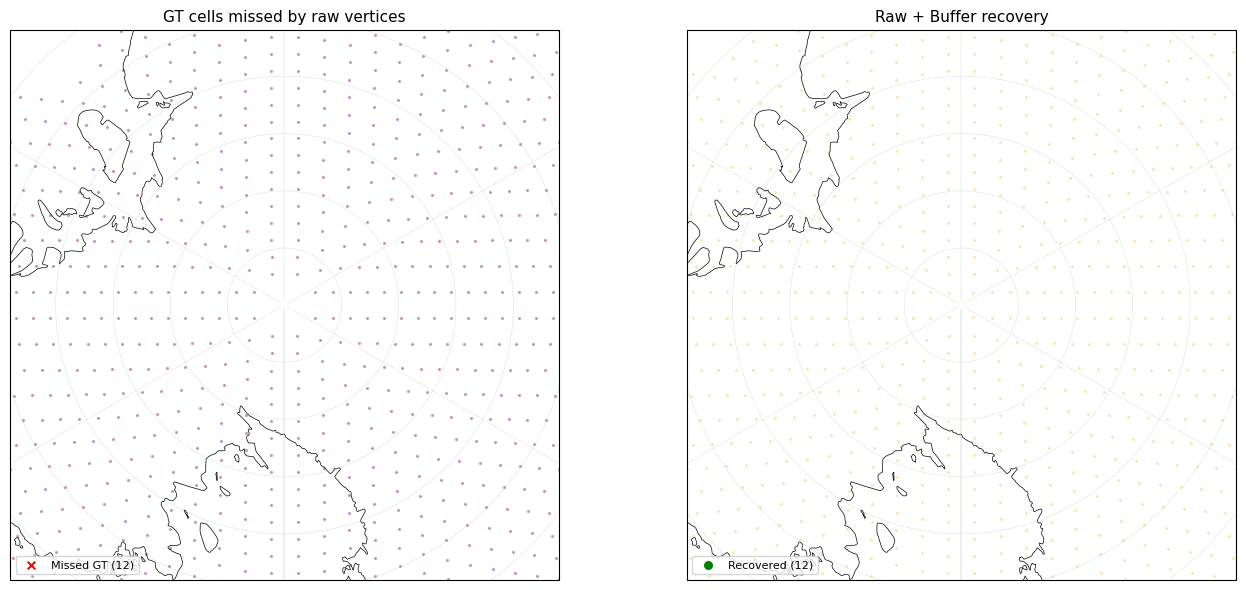

In [14]:
# --- Where Are the Missing Cells? (vs ground truth) ---
# Key question: which real-data cells does each approach miss?

for name, cells in approaches.items():
    missed = ground_truth - cells
    if missed:
        m_arr = np.array(sorted(missed))
        m_la = np.asarray(mort2geo(m_arr)[0])
        pole = np.sum(m_la < -85)
        print(f"{name:<22} misses {len(missed):>3} ground-truth cells "
              f"(lat range [{m_la.min():.1f}, {m_la.max():.1f}], {pole} near pole)")
    else:
        print(f"{name:<22} misses   0 ground-truth cells")

# Zoom plot: ground truth cells missed by raw vertices vs captured by buffer
missed_raw = ground_truth - raw_cells
captured_by_buffer = missed_raw & raw_buffered_cells
still_missed = missed_raw - raw_buffered_cells

print(f"\n--- Raw vertex detail ---")
print(f"Ground truth cells missed by raw: {len(missed_raw)}")
print(f"  Captured by buffer(k=1):        {len(captured_by_buffer)}")
print(f"  Still missed after buffer:      {len(still_missed)}")

if missed_raw:
    miss_arr = np.array(sorted(missed_raw))
    miss_lats, miss_lons = mort2geo(miss_arr)
    miss_lats, miss_lons = np.asarray(miss_lats), np.asarray(miss_lons)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                    subplot_kw={"projection": proj})

    for ax, title in [(ax1, "GT cells missed by raw vertices"),
                       (ax2, "Raw + Buffer recovery")]:
        ax.set_extent([-180, 180, -90, -78], crs=geo)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)
        ax.set_title(title, fontsize=11)

    # Left: missed ground-truth cells over raw vertex coverage
    r_la, r_lo = cells_to_latlon(raw_cells)
    ax1.scatter(r_lo, r_la, s=2, c="purple", transform=geo, alpha=0.3)
    ax1.scatter(miss_lons, miss_lats, s=30, c="red", marker="x",
                transform=geo, zorder=5, label=f"Missed GT ({len(missed_raw)})")
    ax1.legend(loc="lower left", fontsize=8)

    # Right: buffer recovery
    b_la, b_lo = cells_to_latlon(raw_buffered_cells)
    ax2.scatter(b_lo, b_la, s=2, c="orange", transform=geo, alpha=0.2)
    if captured_by_buffer:
        c_arr = np.array(sorted(captured_by_buffer))
        c_la, c_lo = mort2geo(c_arr)
        ax2.scatter(np.asarray(c_lo), np.asarray(c_la), s=30, c="green", marker="o",
                    transform=geo, zorder=5, label=f"Recovered ({len(captured_by_buffer)})")
    if still_missed:
        s_arr = np.array(sorted(still_missed))
        s_la, s_lo = mort2geo(s_arr)
        ax2.scatter(np.asarray(s_lo), np.asarray(s_la), s=30, c="red", marker="x",
                    transform=geo, zorder=5, label=f"Still missed ({len(still_missed)})")
    ax2.legend(loc="lower left", fontsize=8)

    plt.tight_layout()
    plt.show()

In [15]:
# --- The Real Source of the 262M Observation Gap ---
# Non-densified run: 1,107,767,160 obs. Densified run: 1,370,185,727 obs.
# Difference: 262,418,567 obs. The 12 "missing cells" are in S. America /
# Southern Ocean (not Antarctica) and only account for 13,771 obs — irrelevant.
#
# THE PIPELINE:
#   1. CMR returns a GPolygon (~45 vertices) wrapping each granule's ground track
#   2. Catalog builder: geo2mort(vertices, order=18) → clip2order(6) → unique cells
#   3. Each granule URL is added to every cell it touches → catalog[cell] = [urls...]
#   4. Lambda reads a cell: fetches ALL granule HDF5 files listed for that cell,
#      applies spatial + quality filter, aggregates survivors → total_obs
#
# The problem: step 2 only converts the VERTEX POINTS. At high latitudes (-88°),
# polygon edges between vertices span many order-6 cells. Without densification,
# those intermediate cells never get the granule mapped to them.
#
# Example: granule ATL06_20240324...00942311 has 18 cells in raw catalog,
# 34 cells in dense catalog. The 16 extra cells are along the track at -80° to
# -88° where polygon edges cross cells between sparse vertices.
#
# Result: 1,619 of 1,742 shared cells have FEWER granules in the raw catalog.
# Those cells read fewer HDF5 files → fewer observations pass the spatial filter.
# Buffer adds cells to the SET but doesn't add granule MAPPINGS.

# Compare granule counts per cell between raw and dense catalogs
with open("granule_catalog_cycle22_order6_nodensify.json") as f:
    raw_cat = json.load(f)["catalog"]
with open("granule_catalog_cycle22_order6.json") as f:
    dense_cat = json.load(f)["catalog"]

shared = set(int(k) for k in raw_cat) & set(int(k) for k in dense_cat)

extra_by_cell = {}
for cell in shared:
    rg = len(raw_cat[str(cell)])
    dg = len(dense_cat[str(cell)])
    if dg > rg:
        extra_by_cell[cell] = (rg, dg, dg - rg)

total_extra = sum(v[2] for v in extra_by_cell.values())
print(f"Shared cells: {len(shared)}")
print(f"Cells gaining granules from densification: {len(extra_by_cell)}")
print(f"Total extra granule-cell mappings: {total_extra:,}\n")

# Break down by latitude
lat_extra = {}
for cell, (rg, dg, extra) in extra_by_cell.items():
    la = float(mort2geo(cell)[0])
    lat_bin = int(la)
    if lat_bin not in lat_extra:
        lat_extra[lat_bin] = {"cells": 0, "extra": 0}
    lat_extra[lat_bin]["cells"] += 1
    lat_extra[lat_bin]["extra"] += extra

print(f"{'Lat':>5} {'Cells':>6} {'Extra granules':>14} {'Avg/cell':>9}")
print("-" * 38)
for lat in sorted(lat_extra.keys()):
    if lat >= -60:  # skip low-lat noise
        continue
    e = lat_extra[lat]
    print(f"{lat:>4}° {e['cells']:>6} {e['extra']:>14} {e['extra']/e['cells']:>9.1f}")

south85 = sum(v["extra"] for k, v in lat_extra.items() if k <= -85)
print(f"\nExtra mappings south of -85°: {south85:,}/{total_extra:,} ({100*south85/total_extra:.1f}%)")

Shared cells: 1742
Cells gaining granules from densification: 1619
Total extra granule-cell mappings: 25,381

  Lat  Cells Extra granules  Avg/cell
--------------------------------------
 -88°      8           1308     163.5
 -87°     28           2991     106.8
 -86°     20           1300      65.0
 -85°     24           1385      57.7
 -84°     60           2711      45.2
 -83°     36           1158      32.2
 -82°     40           1191      29.8
 -81°     92           2773      30.1
 -80°     52           1586      30.5
 -79°    114           1131       9.9
 -78°     63            328       5.2
 -77°     63            335       5.3
 -76°    134            841       6.3
 -75°     66            532       8.1
 -74°     66            429       6.5
 -73°    133            897       6.7
 -72°     64            475       7.4
 -71°     63            481       7.6
 -70°    120            968       8.1
 -69°     57            439       7.7
 -68°     52            406       7.8
 -67°     90   

/tmp/ipykernel_1669765/2287805947.py:48: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  la = float(mort2geo(cell)[0])


Granule: ...ATL06_20240106000710_02772211_007_01.h5
  Raw catalog cells:   19
  Dense catalog cells: 37
  Extra from densify:  18

  Polygon vertices:     43
  Densified points:     931
  Raw → order-6 cells:  19
  Dense → order-6 cells:37
  Gained cells:         18


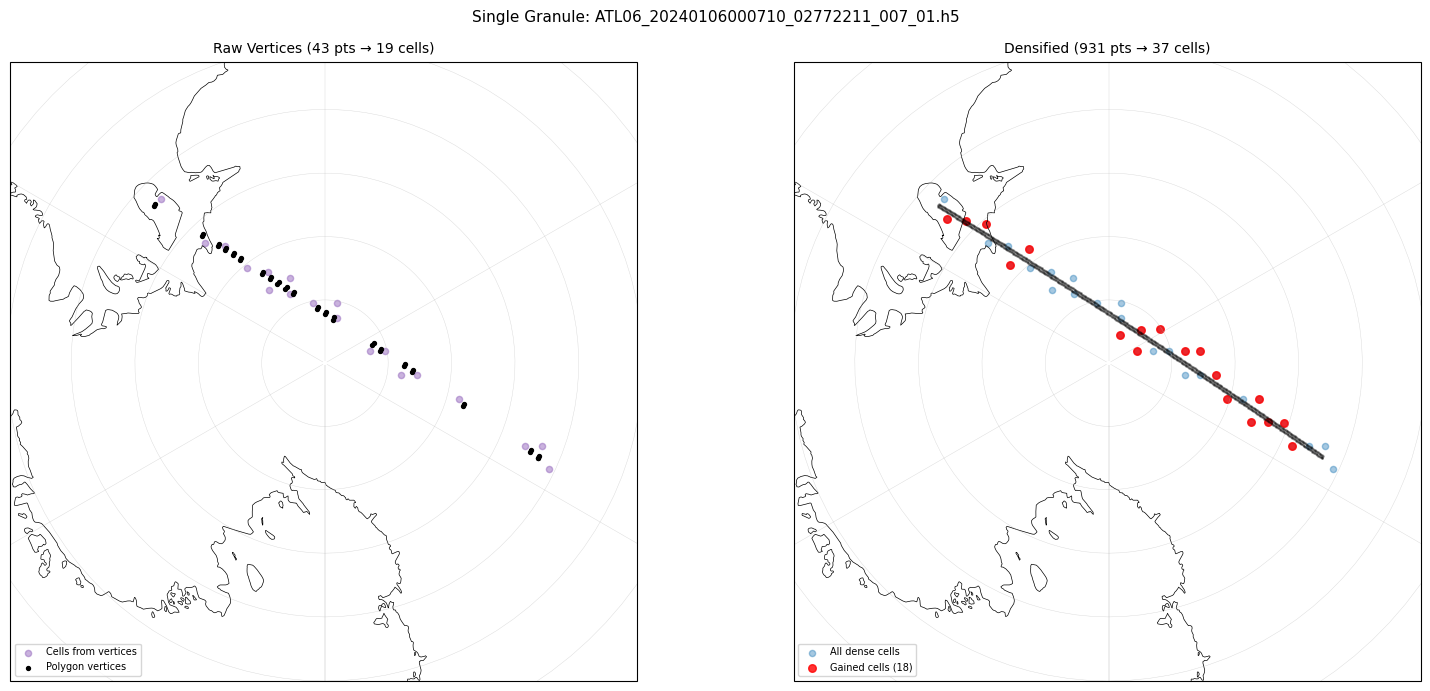

In [16]:
# --- Single-Granule Trace: Why Densification Matters ---
# Pick a granule near the pole that gains the most cells from densification,
# and show what happens to its polygon vertices vs densified points.

from magg.catalog import densify_polygon

target_cell = "-3111112"  # lat -88.54
dense_urls = set(dense_cat[target_cell])
raw_urls = set(raw_cat.get(target_cell, []))
example_url = sorted(dense_urls - raw_urls)[0]

# Find this granule's cells in both catalogs
raw_g_cells = [int(k) for k, urls in raw_cat.items() if example_url in urls]
dense_g_cells = [int(k) for k, urls in dense_cat.items() if example_url in urls]
extra_cells = set(dense_g_cells) - set(raw_g_cells)

print(f"Granule: ...{example_url.split('/')[-1]}")
print(f"  Raw catalog cells:   {len(raw_g_cells)}")
print(f"  Dense catalog cells: {len(dense_g_cells)}")
print(f"  Extra from densify:  {len(extra_cells)}")

# Get this granule's actual polygon from CMR to show raw vs dense points
import requests
granule_id = example_url.split("/")[-1]  # keep .h5 extension
cmr_url = "https://cmr.earthdata.nasa.gov/search/granules.umm_json"
resp = requests.get(cmr_url, params={
    "provider": "NSIDC_CPRD", "short_name": "ATL06", "version": "007",
    "readable_granule_name": granule_id, "page_size": 1,
}, headers={"Accept": "application/vnd.nasa.cmr.umm_json+json"}, timeout=30)
items = resp.json().get("items", [])

if items:
    umm = items[0]["umm"]
    pts = umm["SpatialExtent"]["HorizontalSpatialDomain"]["Geometry"]["GPolygons"][0]["Boundary"]["Points"]
    raw_lats = np.array([p["Latitude"] for p in pts])
    raw_lons = np.array([p["Longitude"] for p in pts])

    dense_lats, dense_lons = densify_polygon(raw_lats, raw_lons, max_spacing_km=5.0)

    # Convert to morton cells
    raw_m18 = geo2mort(raw_lats, raw_lons, order=18)
    raw_m6 = set(int(x) for x in clip2order(6, raw_m18))
    dense_m18 = geo2mort(dense_lats, dense_lons, order=18)
    dense_m6 = set(int(x) for x in clip2order(6, dense_m18))
    gained = dense_m6 - raw_m6

    print(f"\n  Polygon vertices:     {len(raw_lats)}")
    print(f"  Densified points:     {len(dense_lats)}")
    print(f"  Raw → order-6 cells:  {len(raw_m6)}")
    print(f"  Dense → order-6 cells:{len(dense_m6)}")
    print(f"  Gained cells:         {len(gained)}")

    # Plot: raw vertices vs densified points, colored by which cells they hit
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7),
                                    subplot_kw={"projection": proj})

    for ax, title in [(ax1, f"Raw Vertices ({len(raw_lats)} pts → {len(raw_m6)} cells)"),
                       (ax2, f"Densified ({len(dense_lats)} pts → {len(dense_m6)} cells)")]:
        ax.set_extent([-180, 180, -90, -75], crs=geo)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)
        ax.set_title(title, fontsize=10)

    # Left: raw vertices and their cells
    r_la, r_lo = cells_to_latlon(raw_m6)
    ax1.scatter(r_lo, r_la, s=20, c="tab:purple", transform=geo, alpha=0.5, label="Cells from vertices")
    ax1.scatter(raw_lons, raw_lats, s=8, c="black", transform=geo, zorder=5, label="Polygon vertices")
    ax1.legend(loc="lower left", fontsize=7)

    # Right: densified points and their cells, gained cells highlighted
    d_la, d_lo = cells_to_latlon(dense_m6)
    ax2.scatter(d_lo, d_la, s=20, c="tab:blue", transform=geo, alpha=0.4, label="All dense cells")
    if gained:
        g_la, g_lo = cells_to_latlon(gained)
        ax2.scatter(g_lo, g_la, s=30, c="red", transform=geo, alpha=0.8,
                    label=f"Gained cells ({len(gained)})")
    ax2.scatter(dense_lons, dense_lats, s=1, c="black", transform=geo, alpha=0.3)
    ax2.legend(loc="lower left", fontsize=7)

    plt.suptitle(f"Single Granule: {granule_id}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("Could not fetch granule from CMR")

## Conclusions

**The 262M observation gap is NOT about missing cells — it's about missing granule mappings.**

- The non-densified catalog has 1,742 cells; the densified catalog has 2,395.
  But 1,742 cells are shared, and **1,619 of them gain extra granule mappings**
  through densification (25,381 extra mappings total).
- Near the pole hole (-88°), cells gain **60–164 extra granules each**. Without
  densification, those granules are never read, so observations within the cell
  boundary are never discovered by the Lambda.
- `total_obs` = observations that survive **spatial + quality filtering** and are
  used in the output aggregation. More granule mappings → more HDF5 files read →
  more observations pass the spatial filter.
- The 12 cells that only appear in the densified catalog contribute just **13,771 obs**
  (0.001%). The remaining ~262M obs come from shared cells having more granules.
- **Buffer does not solve this.** Buffer expands the *cell set* but does not add
  granule-cell *mappings*. Densification (polygon edge interpolation) is necessary
  to capture all granule-cell relationships, especially near the pole hole where
  CMR polygon edges span many cells between sparse vertices.

**Polygon intersection approach:**
- Uses exact shapely intersection tests (in EPSG:3031) instead of densifying edges.
- Same cell set as raw vertices (~1,742 cells), but with correct granule-cell
  mappings — captures granules whose polygons *intersect* a cell even when no
  vertex falls within it.
- Comparison with densified catalog validates whether densification's approximation
  is accurate or misses/adds spurious mappings.